
## 1. Imports and Setup

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque, namedtuple
import random
import os
import pickle

# reproducibility
random.seed(25)
np.random.seed(25)
torch.manual_seed(25)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda





## 2. Environment Setup: WarehouseRobotEnv
This is a custom 6×6 grid-world environment where an agent (warehouse robot) must:
1. Navigate to a pickup location at (0, 0)
2. Pick up an item
3. Navigate to a dropoff location at (5, 4)
4. Drop off the item

- **Observation space:** Tuple of (row, col, carrying), giving 72 unique states
- **Action space:** 6 discrete actions - Up (0), Down (1), Left (2), Right (3), Pickup (4), Dropoff (5)
- **Obstacles:** Located at (0,2), (2,0), (3,5), (5,3)
- **Rewards:** -1 per step, -20 for hitting obstacle, +25 for pickup, +100 for dropoff (episode ends)
- **Mode:** Deterministic

For DQN, we represent the state as a flat vector [row, col, carrying_int] and pass it through a dense network. No CNN is needed since the state is not image-based.

In [ ]:
class WarehouseRobotEnv(gym.Env):
    """Warehouse Robot Environment"""
    def __init__(self, stochastic=False, slip_prob=0.1):
      super(WarehouseRobotEnv, self).__init__()
      self.stochastic = stochastic
      self.slip_prob = slip_prob
      self.grid_size = 6

      self.pickup_location = (0, 0)
      self.dropoff_location = (5, 4)
      self.obstacles = [(0, 2), (2, 0), (3, 5), (5, 3)]

      self.action_space = spaces.Discrete(6)
      self.observation_space = spaces.Tuple((
              spaces.Discrete(self.grid_size),  # row
              spaces.Discrete(self.grid_size),  # column
              spaces.Discrete(2)                # bool for carry item or not
          ))

      self.agent_pos = None
      self.carrying_item = False
      self.done = False

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        valid_start = False
        while not valid_start:
            self.agent_pos = [np.random.randint(0, self.grid_size),
                             np.random.randint(0, self.grid_size)]
            if tuple(self.agent_pos) not in self.obstacles:
                valid_start = True
        self.carrying_item = False
        self.done = False
        observation = self._get_observation()
        info = {}
        return observation, info

    def step(self, action):
        if self.done:
            return self._get_observation(), 0, True, False, {}

        reward = -1
        old_pos = self.agent_pos.copy()

        if action < 4:
            moved = False
            if self.stochastic:
                if np.random.random() >= self.slip_prob:
                    moved = True
            else:
                moved = True

            if moved:
                if action == 0:  # Up
                    self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
                elif action == 1:  # Down
                    self.agent_pos[0] = min(self.grid_size - 1, self.agent_pos[0] + 1)
                elif action == 2:  # Left
                    self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
                elif action == 3:  # Right
                    self.agent_pos[1] = min(self.grid_size - 1, self.agent_pos[1] + 1)

            if tuple(self.agent_pos) in self.obstacles:
                self.agent_pos = old_pos
                reward = -20

        elif action == 4:
            if tuple(self.agent_pos) == self.pickup_location and not self.carrying_item:
                self.carrying_item = True
                reward = 25

        elif action == 5:
            if tuple(self.agent_pos) == self.dropoff_location and self.carrying_item:
                reward = 100
                self.done = True

        observation = self._get_observation()
        terminated = self.done
        truncated = False
        info = {}
        return observation, reward, terminated, truncated, info

    def _get_observation(self):
        return (self.agent_pos[0], self.agent_pos[1], int(self.carrying_item))

    def render(self):
        grid = np.zeros((self.grid_size, self.grid_size))
        for obs in self.obstacles:
            grid[obs] = 0.3
        grid[self.pickup_location] = 0.6
        grid[self.dropoff_location] = 0.8
        grid[tuple(self.agent_pos)] = 1.0

        plt.figure(figsize=(6, 6))
        plt.imshow(grid, cmap='viridis', interpolation='nearest')
        for i in range(self.grid_size + 1):
            plt.axhline(i - 0.5, color='black', linewidth=1)
            plt.axvline(i - 0.5, color='black', linewidth=1)
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                if (i, j) in self.obstacles:
                    plt.text(j, i, 'X', ha='center', va='center',
                            color='white', fontsize=16, fontweight='bold')
                elif (i, j) == self.pickup_location:
                    plt.text(j, i, 'P', ha='center', va='center',
                            color='lime', fontsize=16, fontweight='bold')
                elif (i, j) == self.dropoff_location:
                    plt.text(j, i, 'D', ha='center', va='center',
                            color='cyan', fontsize=16, fontweight='bold')
                elif (i, j) == tuple(self.agent_pos):
                    agent_symbol = 'A+' if self.carrying_item else 'A'
                    agent_color = 'orange' if self.carrying_item else 'red'
                    plt.text(j, i, agent_symbol, ha='center', va='center',
                            color=agent_color, fontsize=16, fontweight='bold')
        status = "Carrying" if self.carrying_item else "Not Carrying"
        mode = "Stochastic" if self.stochastic else "Deterministic"
        plt.title(f'Warehouse Robot - {mode}\nStatus: {status}',
                 fontsize=12, fontweight='bold')
        plt.xlabel('Column')
        plt.ylabel('Row')
        plt.xticks(range(self.grid_size))
        plt.yticks(range(self.grid_size))
        plt.tight_layout()
        plt.show()

In [3]:
# quick env test
env_test = WarehouseRobotEnv(stochastic=False)
obs, _ = env_test.reset()
print(f"Grid size: {env_test.grid_size}")
print(f"Action space: {env_test.action_space}")
print(f"Observation: {obs}")
print(f"Pickup: {env_test.pickup_location}, Dropoff: {env_test.dropoff_location}")
print(f"Obstacles: {env_test.obstacles}")

Grid size: 6
Action space: Discrete(6)
Observation: (4, 2, 0)
Pickup: (0, 0), Dropoff: (5, 4)
Obstacles: [(0, 2), (2, 0), (3, 5), (5, 3)]


## 3. DQN
### Grid-World (WarehouseRobotEnv)
- **Input:** 3 features - [row, col, carrying_flag]
- **Architecture:** 3 -> 64 (ReLU) -> 64 (ReLU) -> 6 (linear)
- **Rationale:** The state space is small (72 states), so a two-layer network with 64 hidden units is sufficient. The 6 output neurons correspond to the 6 actions.


In [4]:
# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

In [5]:
# Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [6]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, hidden_dim=64, lr=1e-4,
                 gamma=0.99, epsilon_start=1.0, epsilon_end=0.01,
                 epsilon_decay=0.995, buffer_size=10000, batch_size=64,
                 target_update_freq=10, tau=None):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.tau = tau

        # networks
        self.q_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer(buffer_size)

        self.steps_done = 0
        self.episodes_done = 0

    def select_action(self, state, greedy=False):
        if greedy or random.random() > self.epsilon:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.q_network(state_t)
                return q_values.argmax(dim=1).item()
        else:
            return random.randrange(self.action_dim)

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)

        states_t = torch.FloatTensor(states).to(device)
        actions_t = torch.LongTensor(actions).to(device)
        rewards_t = torch.FloatTensor(rewards).to(device)
        next_states_t = torch.FloatTensor(next_states).to(device)
        dones_t = torch.FloatTensor(dones).to(device)

        curr_q = self.q_network(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        # target Q values
        with torch.no_grad():
            next_q = self.target_network(next_states_t).max(dim=1)[0]
            target_q = rewards_t + self.gamma * next_q * (1 - dones_t)

        loss = self.loss_fn(curr_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        # soft update target network if tau is set
        if self.tau is not None:
            self.soft_update_target_network()

        return loss.item()

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def soft_update_target_network(self):
        for target_param, online_param in zip(
            self.target_network.parameters(), self.q_network.parameters()):
            target_param.data.copy_(
                self.tau * online_param.data + (1.0 - self.tau) * target_param.data
            )

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [7]:
def state_to_array(obs):
    """Convert observation to numpy array for the network."""
    if isinstance(obs, tuple):
        return np.array(obs, dtype=np.float32)
    return np.array(obs, dtype=np.float32)


def train_dqn(env, agent, num_episodes, max_steps=500, print_every=100,
              state_converter=state_to_array, reward_shaper=None):
    all_rewards = []
    all_losses = []
    all_epsilons = []

    for ep in range(num_episodes):
        obs, _ = env.reset()
        state = state_converter(obs)
        total_reward = 0
        ep_losses = []

        for step in range(max_steps):
            action = agent.select_action(state)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = state_converter(next_obs)

            shaped_reward = reward_shaper(obs, next_obs, reward, done) if reward_shaper else reward

            agent.store_transition(state, action, shaped_reward, next_state, float(done))
            loss = agent.train_step()
            if loss is not None:
                ep_losses.append(loss)

            total_reward += reward  # track original reward
            state = next_state
            obs = next_obs
            agent.steps_done += 1

            if done:
                break

        agent.decay_epsilon()
        agent.episodes_done += 1

        # update target network periodically
        if agent.episodes_done % agent.target_update_freq == 0:
            agent.update_target_network()
        if agent.tau is None:
            # hard update: completely replace target network weights
            if agent.episodes_done % agent.target_update_freq == 0:
                agent.update_target_network()

        avg_loss = np.mean(ep_losses) if ep_losses else 0
        all_rewards.append(total_reward)
        all_losses.append(avg_loss)
        all_epsilons.append(agent.epsilon)

        if (ep + 1) % print_every == 0:
            recent_avg = np.mean(all_rewards[-print_every:])
            print(f"Episode {ep+1}/{num_episodes} | "
                  f"Avg Reward (last {print_every}): {recent_avg:.2f} | "
                  f"Epsilon: {agent.epsilon:.4f} | "
                  f"Avg Loss: {avg_loss:.4f}")

    return all_rewards, all_losses, all_epsilons


def evaluate_dqn(env, agent, num_episodes=10, max_steps=500,
                 state_converter=state_to_array, render=False):
    """Evaluate using greedy policy"""
    eval_rewards = []
    for ep in range(num_episodes):
        obs, _ = env.reset()
        state = state_converter(obs)
        total_reward = 0

        for step in range(max_steps):
            action = agent.select_action(state, greedy=True)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if render and ep == 0:
                print(f"Step {step+1}: pos={obs}, action={action}, reward={reward}")
                env.render()

            total_reward += reward
            state = state_converter(next_obs)
            obs = next_obs

            if done:
                break

        eval_rewards.append(total_reward)
        print(f"Eval Episode {ep+1}: Total Reward = {total_reward}")

    avg_reward = np.mean(eval_rewards)
    print(f"\nAverage evaluation reward over {num_episodes} episodes: {avg_reward:.2f}")
    return eval_rewards

In [8]:
def plot_training_results(rewards, losses, epsilons, title_prefix=""):
    """Plot training reward, loss, and epsilon decay."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # reward plot
    axes[0].plot(rewards, alpha=0.6, label='Episode Reward')
    window = min(50, len(rewards)//5) if len(rewards) > 10 else 1
    if window > 1:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(rewards)), smoothed, color='red',
                    linewidth=2, label=f'Moving Avg ({window} ep)')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title(f'{title_prefix} - Total Reward per Episode')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # loss plot
    axes[1].plot(losses, alpha=0.6, color='orange')
    if window > 1 and len(losses) > window:
        smoothed_loss = np.convolve(losses, np.ones(window)/window, mode='valid')
        axes[1].plot(range(window-1, len(losses)), smoothed_loss, color='red', linewidth=2)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Average Loss')
    axes[1].set_title(f'{title_prefix} - Training Loss per Episode')
    axes[1].grid(True, alpha=0.3)

    # epsilon plot
    axes[2].plot(epsilons, color='green')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Epsilon')
    axes[2].set_title(f'{title_prefix} - Epsilon Decay')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_eval_results(eval_rewards, title_prefix=""):
    plt.figure(figsize=(8, 5))
    plt.bar(range(1, len(eval_rewards)+1), eval_rewards, color='steelblue', alpha=0.7)
    plt.axhline(y=np.mean(eval_rewards), color='red', linestyle='--',
                label=f'Mean: {np.mean(eval_rewards):.2f}')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title(f'{title_prefix} - Evaluation Rewards (Greedy Policy)')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 7. Training DQN on Grid-World Environment

We train DQN on our WarehouseRobotEnv. The state (row, col, carrying) is directly used as a 3-element input vector.

In [ ]:
# set up grid-world environment
gridworld_env = WarehouseRobotEnv(stochastic=False)

# hyperparameters
gridworld_agent = DQNAgent(
    state_dim=3, # row, col, carrying
    action_dim=6,
    hidden_dim=64,
    lr=5e-4,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995,
    buffer_size=20000,
    batch_size=64,
    target_update_freq=10
)

print("Training DQN on Grid-World (8000 episodes)")
gw_rewards, gw_losses, gw_epsilons = train_dqn(
    gridworld_env, gridworld_agent,
    num_episodes=8000, max_steps=200, print_every=500
)

Training DQN on Grid-World (8000 episodes)
Episode 500/8000 | Avg Reward (last 500): -274.22 | Epsilon: 0.7788 | Avg Loss: 0.1002
Episode 1000/8000 | Avg Reward (last 500): 10.78 | Epsilon: 0.6065 | Avg Loss: 0.0084
Episode 1500/8000 | Avg Reward (last 500): 61.79 | Epsilon: 0.4723 | Avg Loss: 0.0055
Episode 2000/8000 | Avg Reward (last 500): 82.83 | Epsilon: 0.3678 | Avg Loss: 0.0075
Episode 2500/8000 | Avg Reward (last 500): 91.25 | Epsilon: 0.2864 | Avg Loss: 0.0055
Episode 3000/8000 | Avg Reward (last 500): 97.36 | Epsilon: 0.2230 | Avg Loss: 0.0053
Episode 3500/8000 | Avg Reward (last 500): 101.11 | Epsilon: 0.1737 | Avg Loss: 0.0038
Episode 4000/8000 | Avg Reward (last 500): 104.02 | Epsilon: 0.1353 | Avg Loss: 0.0044
Episode 4500/8000 | Avg Reward (last 500): 105.35 | Epsilon: 0.1053 | Avg Loss: 0.0153
Episode 5000/8000 | Avg Reward (last 500): 106.65 | Epsilon: 0.0820 | Avg Loss: 0.0055
Episode 5500/8000 | Avg Reward (last 500): 108.01 | Epsilon: 0.0639 | Avg Loss: 0.0029
Episo

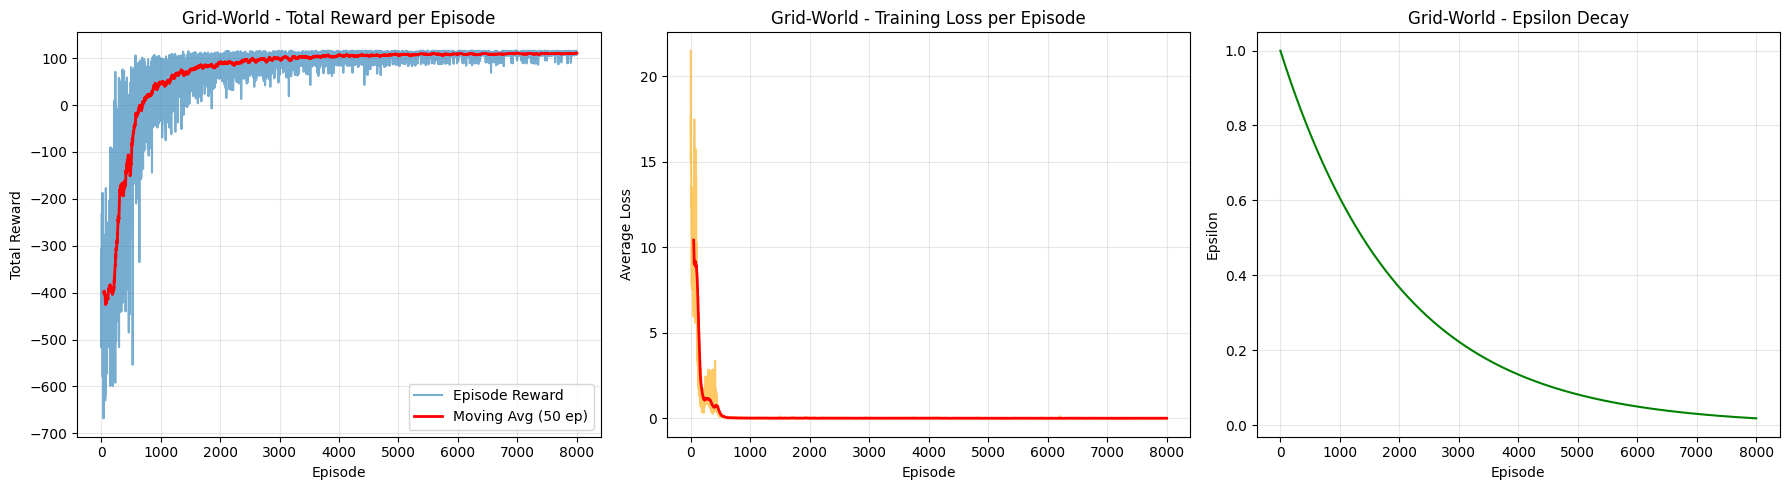

In [ ]:
# Ploting results
plot_training_results(gw_rewards, gw_losses, gw_epsilons, "Grid-World")

In [ ]:
# Evaluate grid-world with greedy policy
gw_eval_rewards = evaluate_dqn(gridworld_env, gridworld_agent, num_episodes=10, max_steps=200)

Eval Episode 1: Total Reward = 110
Eval Episode 2: Total Reward = 115
Eval Episode 3: Total Reward = 110
Eval Episode 4: Total Reward = 115
Eval Episode 5: Total Reward = 110
Eval Episode 6: Total Reward = 111
Eval Episode 7: Total Reward = 110
Eval Episode 8: Total Reward = 106
Eval Episode 9: Total Reward = 112
Eval Episode 10: Total Reward = 108

Average evaluation reward over 10 episodes: 110.70


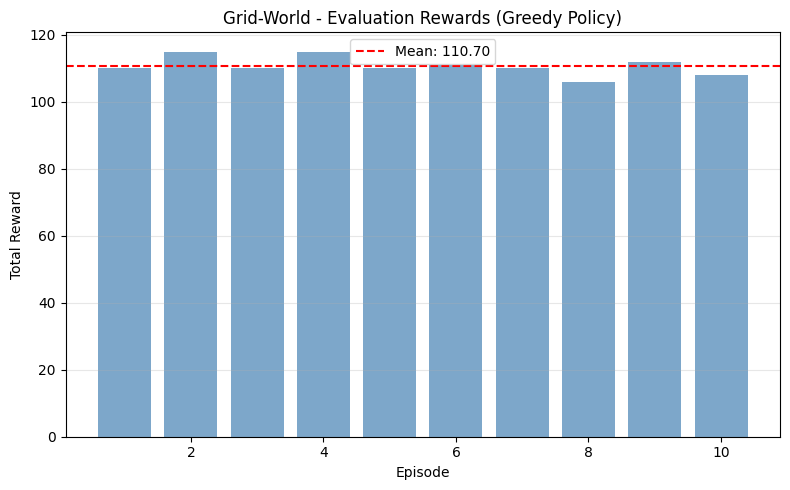

In [ ]:
# Plot grid-world evaluation
plot_eval_results(gw_eval_rewards, "Grid-World")

### Grid-World: Greedy Episode Rendering
Below we run 1 greedy evaluation episode and render each step to verify the agent completes pickup and dropoff correctly.

Greedy Episode Rendering
Initial position: (0, 3, 0)


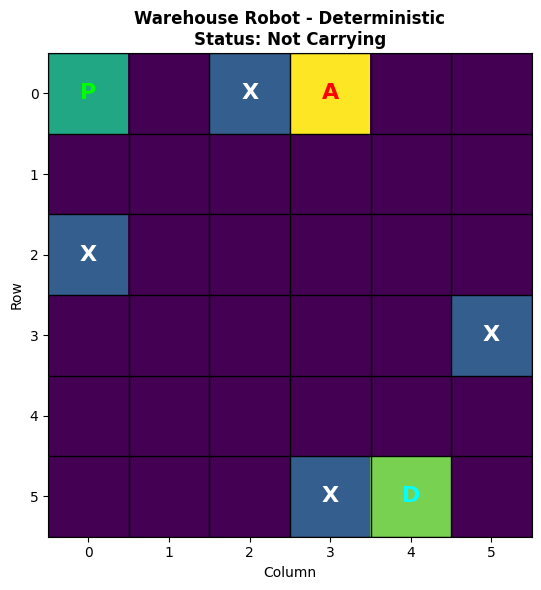


Step 1: Action = Down, Reward = -1, New Position = (1, 3, 0), Cumulative Reward = -1


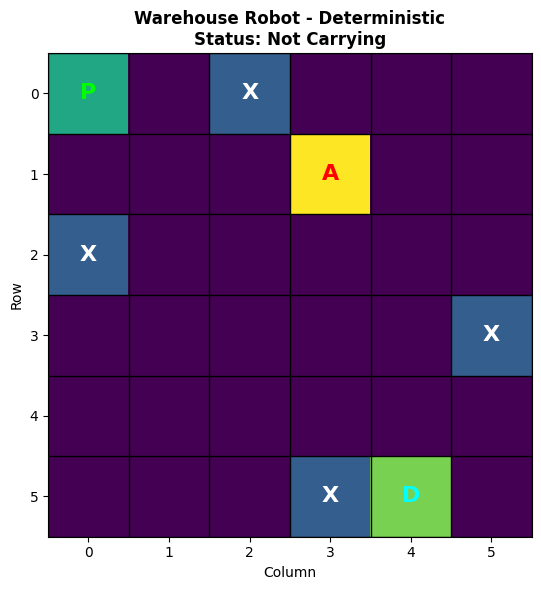


Step 2: Action = Left, Reward = -1, New Position = (1, 2, 0), Cumulative Reward = -2


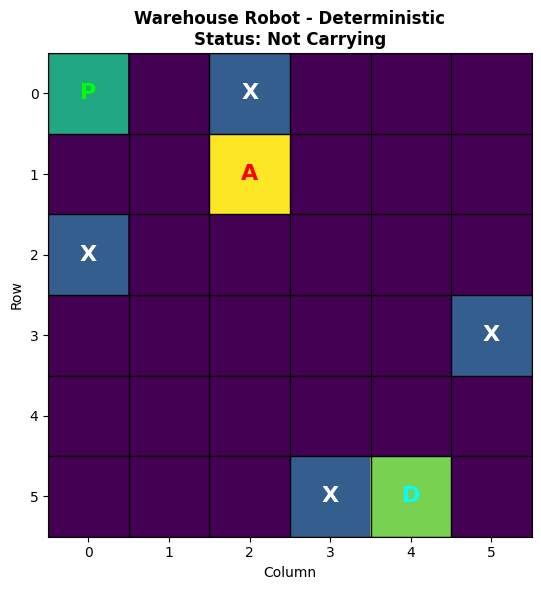


Step 3: Action = Left, Reward = -1, New Position = (1, 1, 0), Cumulative Reward = -3


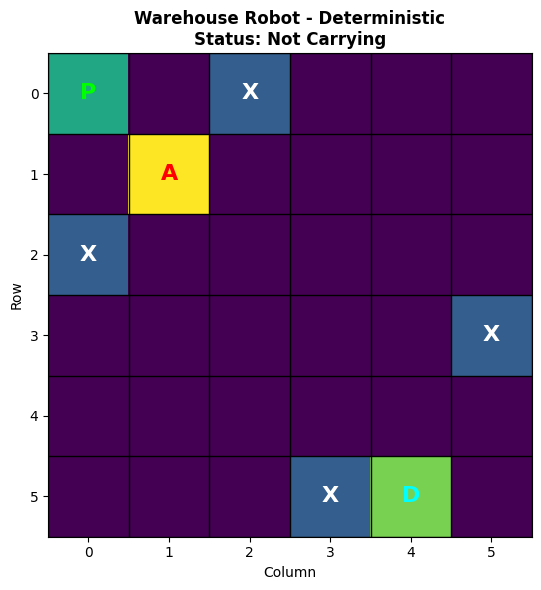


Step 4: Action = Left, Reward = -1, New Position = (1, 0, 0), Cumulative Reward = -4


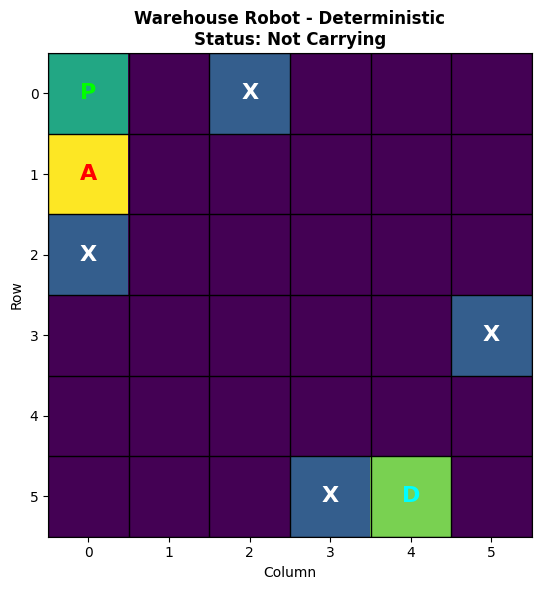


Step 5: Action = Up, Reward = -1, New Position = (0, 0, 0), Cumulative Reward = -5


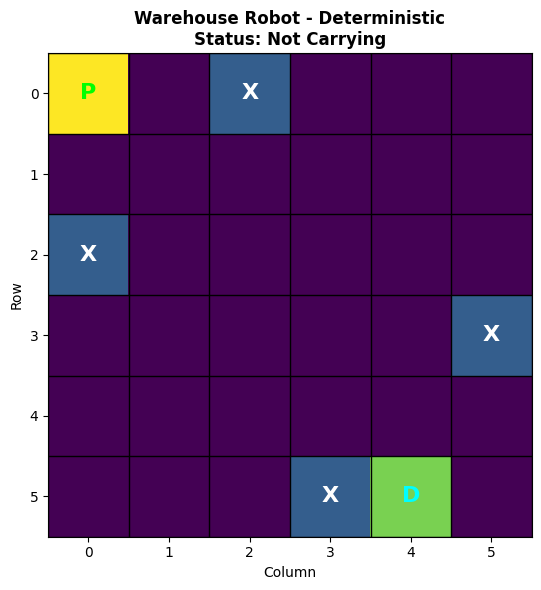


Step 6: Action = Pickup, Reward = 25, New Position = (0, 0, 1), Cumulative Reward = 20


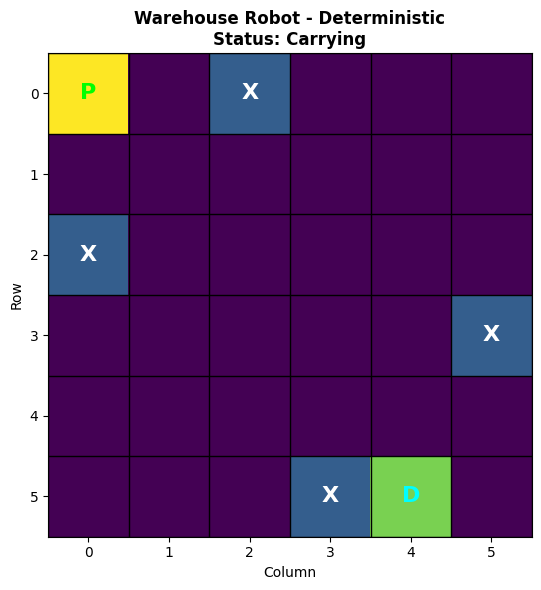


Step 7: Action = Right, Reward = -1, New Position = (0, 1, 1), Cumulative Reward = 19


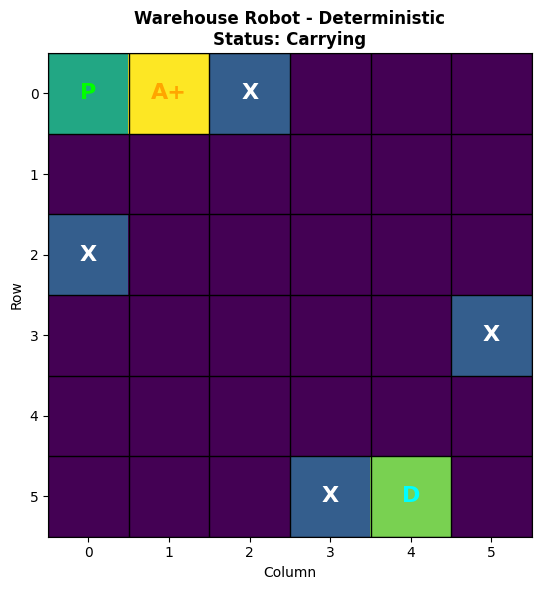


Step 8: Action = Down, Reward = -1, New Position = (1, 1, 1), Cumulative Reward = 18


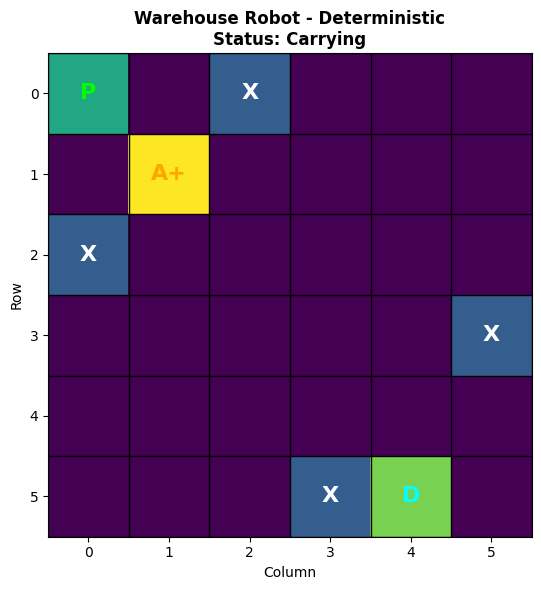


Step 9: Action = Down, Reward = -1, New Position = (2, 1, 1), Cumulative Reward = 17


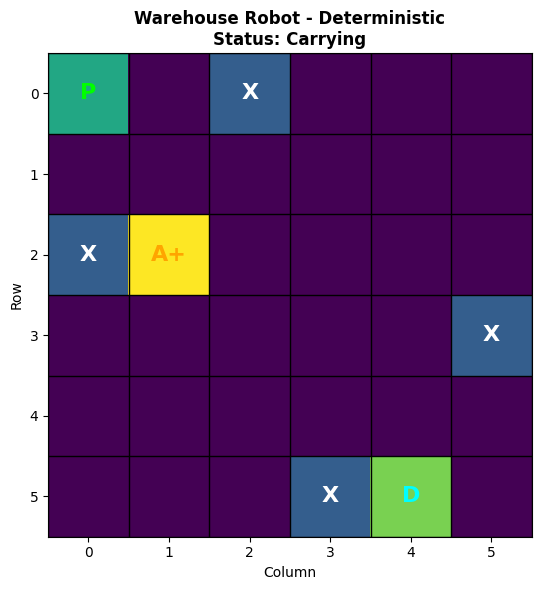


Step 10: Action = Down, Reward = -1, New Position = (3, 1, 1), Cumulative Reward = 16


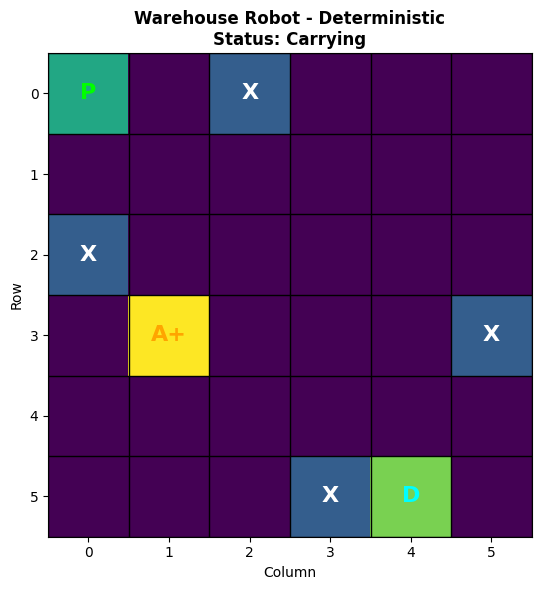


Step 11: Action = Right, Reward = -1, New Position = (3, 2, 1), Cumulative Reward = 15


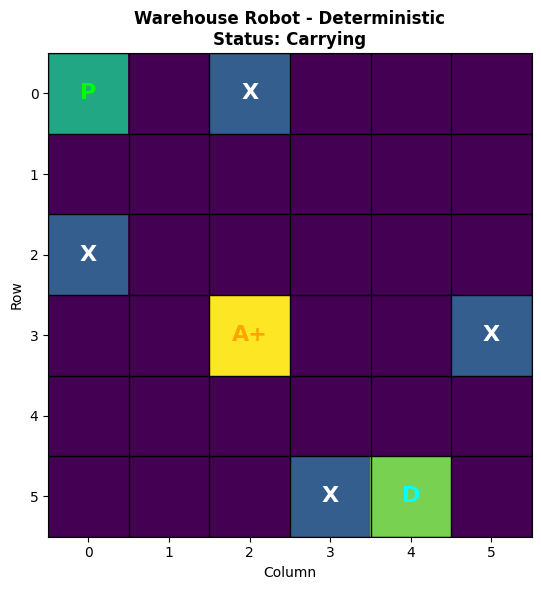


Step 12: Action = Right, Reward = -1, New Position = (3, 3, 1), Cumulative Reward = 14


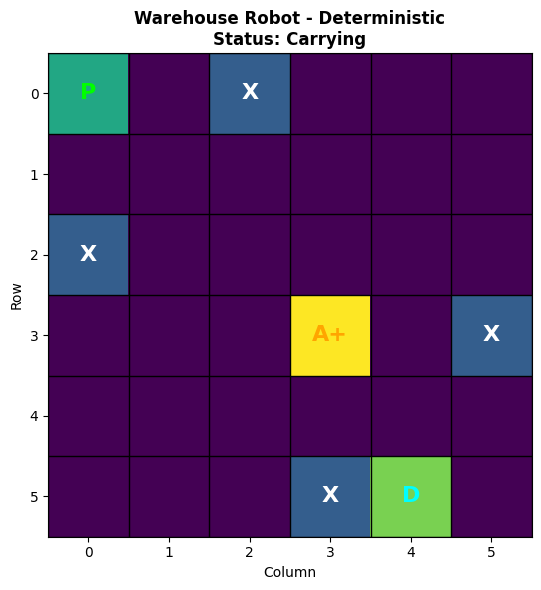


Step 13: Action = Right, Reward = -1, New Position = (3, 4, 1), Cumulative Reward = 13


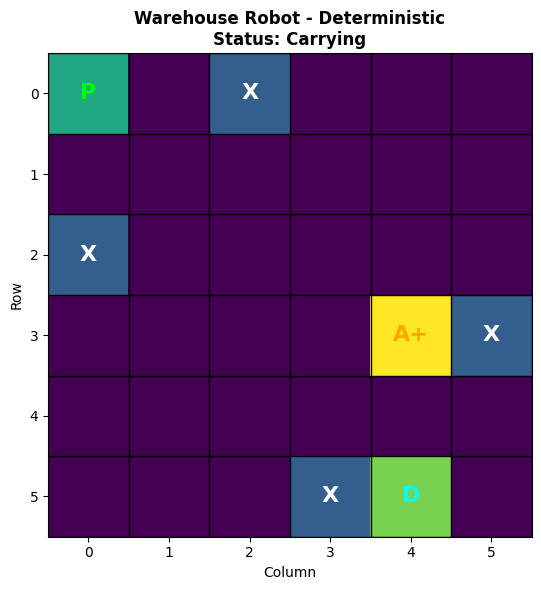


Step 14: Action = Down, Reward = -1, New Position = (4, 4, 1), Cumulative Reward = 12


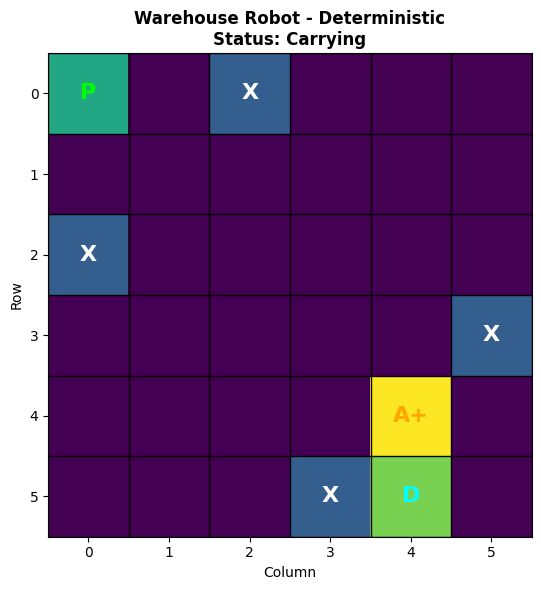


Step 15: Action = Down, Reward = -1, New Position = (5, 4, 1), Cumulative Reward = 11


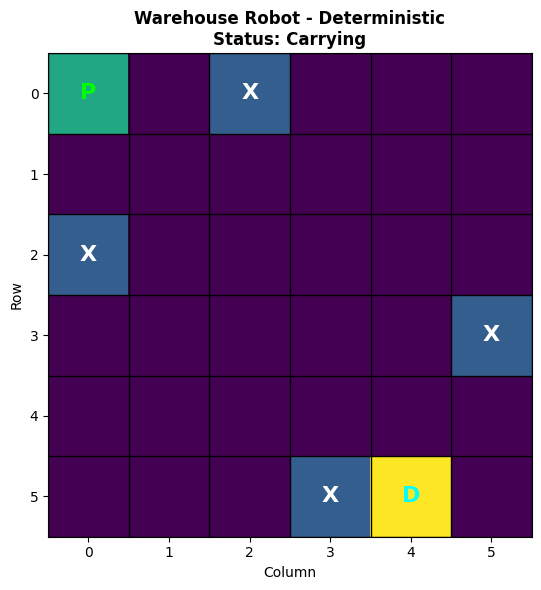


Step 16: Action = Dropoff, Reward = 100, New Position = (5, 4, 1), Cumulative Reward = 111


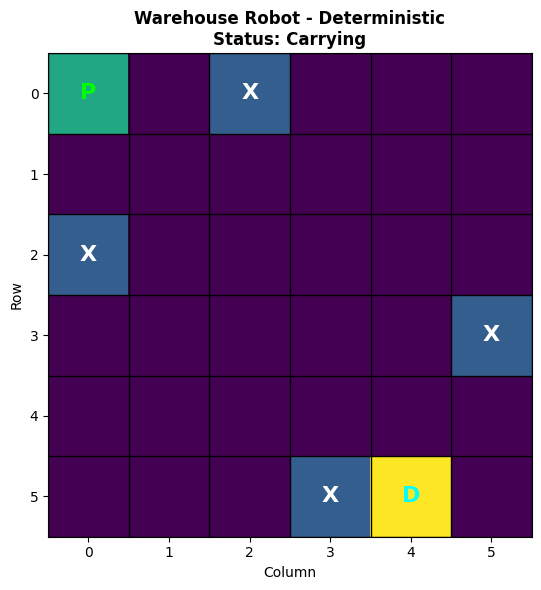


Episode finished in 16 steps with total reward: 111


In [ ]:
# Render 1 greedy episode on grid-world
print("Greedy Episode Rendering")
gw_render_env = WarehouseRobotEnv(stochastic=False)
obs, _ = gw_render_env.reset(seed=42)
state = state_to_array(obs)
total_reward = 0
action_names = ['Up', 'Down', 'Left', 'Right', 'Pickup', 'Dropoff']

print(f"Initial position: {obs}")
gw_render_env.render()

for step in range(200):
    action = gridworld_agent.select_action(state, greedy=True)
    next_obs, reward, terminated, truncated, info = gw_render_env.step(action)
    done = terminated or truncated
    total_reward += reward

    print(f"\nStep {step+1}: Action = {action_names[action]}, "
          f"Reward = {reward}, New Position = {next_obs}, "
          f"Cumulative Reward = {total_reward}")
    gw_render_env.render()

    state = state_to_array(next_obs)
    obs = next_obs
    if done:
        print(f"\nEpisode finished in {step+1} steps with total reward: {total_reward}")
        break

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
torch.save(gridworld_agent.q_network.state_dict(),
    '/content/drive/MyDrive/a2_part_2_dqn_gridworld_JeetKavaiya_GandharSidhaye.pth')

## 8. Training DQN on CartPole-v1

In [ ]:
# set up CartPole environment
cartpole_env = gym.make('CartPole-v1')

# hyperparameters for CartPole
cartpole_agent = DQNAgent(
    state_dim=4, # position, velocity, angle, angular_velocity
    action_dim=2,
    hidden_dim=32,
    lr=1e-4,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.998,
    buffer_size=50000,
    batch_size=64,
    target_update_freq=10,
    tau = 0.05
)

print("Training DQN on CartPole-v1")
cp_rewards, cp_losses, cp_epsilons = train_dqn(cartpole_env, cartpole_agent, num_episodes=3000, max_steps=500, print_every=500)

Training DQN on CartPole-v1
Episode 500/3000 | Avg Reward (last 500): 26.06 | Epsilon: 0.3675 | Avg Loss: 25.8859
Episode 1000/3000 | Avg Reward (last 500): 299.68 | Epsilon: 0.1351 | Avg Loss: 17.0858
Episode 1500/3000 | Avg Reward (last 500): 454.67 | Epsilon: 0.0496 | Avg Loss: 11.9779
Episode 2000/3000 | Avg Reward (last 500): 486.30 | Epsilon: 0.0182 | Avg Loss: 9.7830
Episode 2500/3000 | Avg Reward (last 500): 494.66 | Epsilon: 0.0100 | Avg Loss: 16.9282
Episode 3000/3000 | Avg Reward (last 500): 336.43 | Epsilon: 0.0100 | Avg Loss: 15.5341


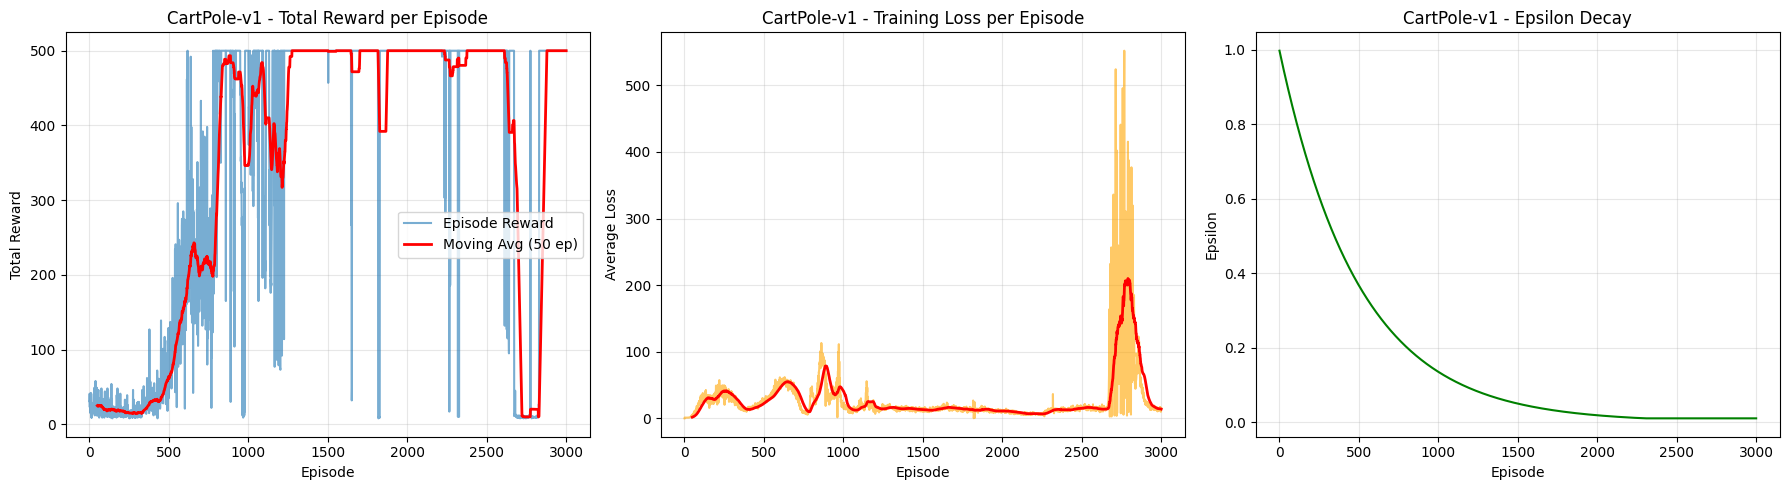

In [ ]:
plot_training_results(cp_rewards, cp_losses, cp_epsilons, "CartPole-v1")

In [ ]:
# Evaluate CartPole
print("Evaluating CartPole-v1 with greedy policy")
cp_eval_rewards = evaluate_dqn(cartpole_env, cartpole_agent, num_episodes=10, max_steps=500)

Evaluating CartPole-v1 with greedy policy
Eval Episode 1: Total Reward = 500.0
Eval Episode 2: Total Reward = 500.0
Eval Episode 3: Total Reward = 500.0
Eval Episode 4: Total Reward = 500.0
Eval Episode 5: Total Reward = 500.0
Eval Episode 6: Total Reward = 500.0
Eval Episode 7: Total Reward = 500.0
Eval Episode 8: Total Reward = 500.0
Eval Episode 9: Total Reward = 500.0
Eval Episode 10: Total Reward = 500.0

Average evaluation reward over 10 episodes: 500.00


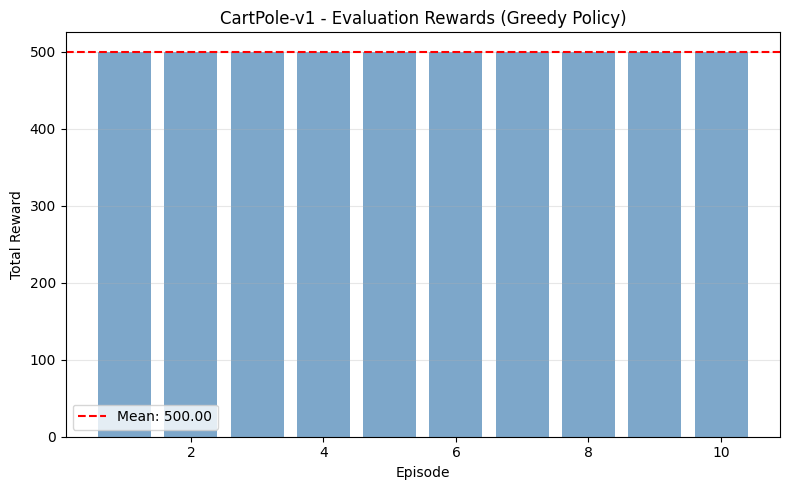

In [ ]:
plot_eval_results(cp_eval_rewards, "CartPole-v1")

In [ ]:
torch.save(cartpole_agent.q_network.state_dict(),
           '/content/drive/MyDrive/a2_part_2_dqn_cartpole_JeetKavaiya_GandharSidhaye.pth')

## 9. Training DQN on MountainCar-v0

MountainCar-v0 has a very sparse reward signal (-1 per step), making it extremely difficult for vanilla DQN to learn. To help with convergence, we use a **custom reward function during training** that provides a bonus based on how high the car gets (encouraging it to climb higher). However, **evaluation uses the original reward function** to determine whether the solve criterion (average reward > -110) has been met.

### Custom Reward for Training
We shape the reward by adding a bonus based on the car's position. The car starts around position -0.5, and the goal is at position >= 0.5. We reward higher positions to guide the agent toward the goal.


In [12]:
def mountaincar_reward(obs, next_obs, original_reward, done):
    position = next_obs[0] if hasattr(next_obs, '__len__') else next_obs
    velocity = next_obs[1] if hasattr(next_obs, '__len__') else 0

    # position ranges from -1.2 to 0.6
    pos_bonus = (position + 1.2) / 1.8 # normalize to [0, 1]

    vel_bonus = abs(velocity) * 10
    shaped_reward = original_reward + pos_bonus + vel_bonus

    # big bonus if reached the goal
    if done and position >= 0.5:
        shaped_reward += 100

    return shaped_reward

In [13]:
# set up MountainCar environment
mountaincar_env = gym.make('MountainCar-v0')

# hyperparameters for MountainCar
mountaincar_agent = DQNAgent(
    state_dim=2,       
    action_dim=3,  
    hidden_dim=128,
    lr=1e-3,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995,
    buffer_size=50000,
    batch_size=64,
    target_update_freq=10,
)

print("Training DQN on MountainCar-v0")
mc_rewards, mc_losses, mc_epsilons = train_dqn(
    mountaincar_env, mountaincar_agent,
    num_episodes=10000, max_steps=200, print_every=500,
    reward_shaper=mountaincar_reward
)

Training DQN on MountainCar-v0
Episode 500/10000 | Avg Reward (last 500): -200.00 | Epsilon: 0.7788 | Avg Loss: 0.4711
Episode 1000/10000 | Avg Reward (last 500): -200.00 | Epsilon: 0.6065 | Avg Loss: 0.2836
Episode 1500/10000 | Avg Reward (last 500): -198.83 | Epsilon: 0.4723 | Avg Loss: 3.4540
Episode 2000/10000 | Avg Reward (last 500): -192.53 | Epsilon: 0.3678 | Avg Loss: 10.2040
Episode 2500/10000 | Avg Reward (last 500): -191.05 | Epsilon: 0.2864 | Avg Loss: 11.8112
Episode 3000/10000 | Avg Reward (last 500): -191.73 | Epsilon: 0.2230 | Avg Loss: 6.8446
Episode 3500/10000 | Avg Reward (last 500): -188.24 | Epsilon: 0.1737 | Avg Loss: 8.4461
Episode 4000/10000 | Avg Reward (last 500): -167.24 | Epsilon: 0.1353 | Avg Loss: 6.1382
Episode 4500/10000 | Avg Reward (last 500): -143.73 | Epsilon: 0.1053 | Avg Loss: 0.4938
Episode 5000/10000 | Avg Reward (last 500): -129.49 | Epsilon: 0.0820 | Avg Loss: 1.6228
Episode 5500/10000 | Avg Reward (last 500): -120.13 | Epsilon: 0.0639 | Avg Lo

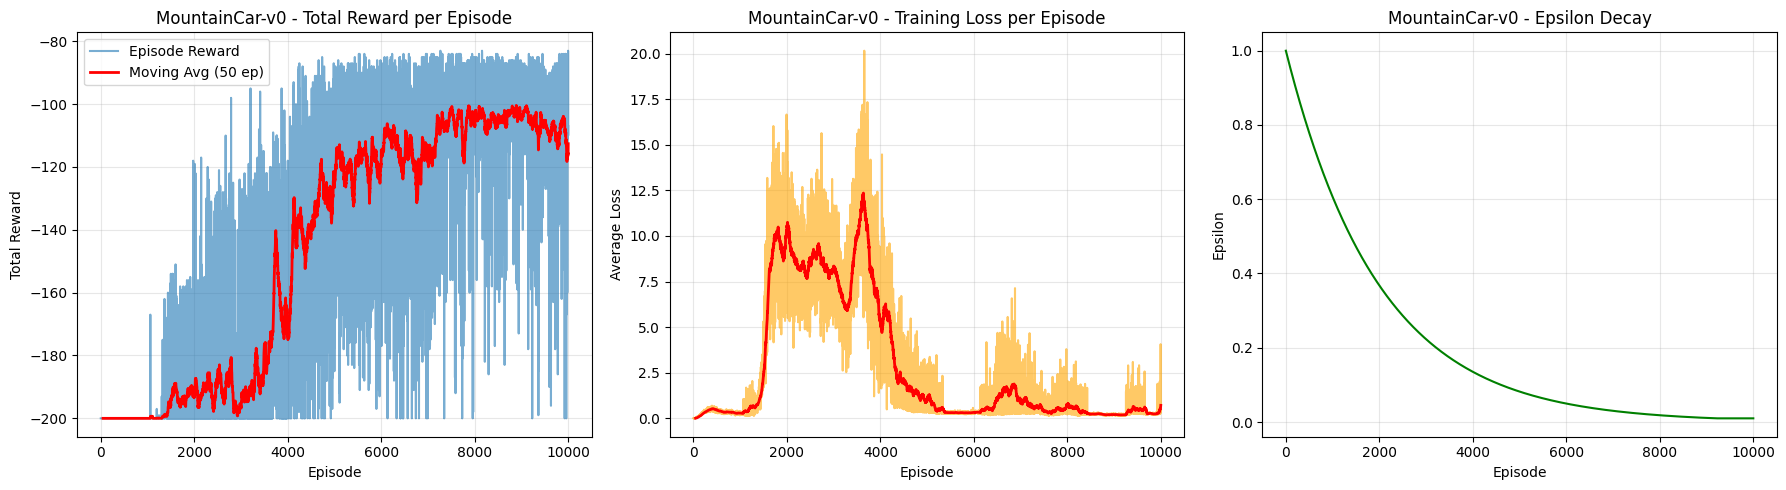

In [14]:
plot_training_results(mc_rewards, mc_losses, mc_epsilons, "MountainCar-v0")

In [15]:
# Evaluate MountainCar with ORIGINAL reward
print("Evaluating MountainCar-v0 with greedy policy")
mc_eval_rewards = evaluate_dqn(mountaincar_env, mountaincar_agent, num_episodes=10, max_steps=200)

Evaluating MountainCar-v0 with greedy policy
Eval Episode 1: Total Reward = -84.0
Eval Episode 2: Total Reward = -91.0
Eval Episode 3: Total Reward = -108.0
Eval Episode 4: Total Reward = -104.0
Eval Episode 5: Total Reward = -106.0
Eval Episode 6: Total Reward = -107.0
Eval Episode 7: Total Reward = -95.0
Eval Episode 8: Total Reward = -106.0
Eval Episode 9: Total Reward = -105.0
Eval Episode 10: Total Reward = -87.0

Average evaluation reward over 10 episodes: -99.30


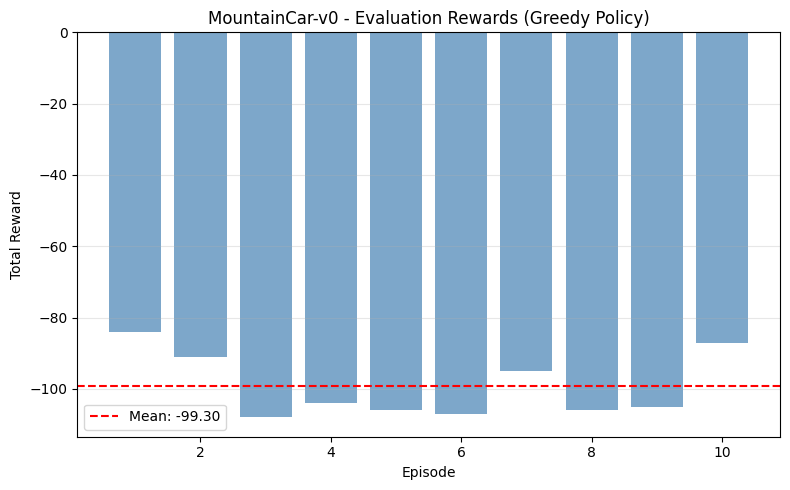

In [16]:
plot_eval_results(mc_eval_rewards, "MountainCar-v0")

In [17]:
torch.save(mountaincar_agent.q_network.state_dict(),
           '/content/drive/MyDrive/a2_part_2_dqn_mountaincar_JeetKavaiya_GandharSidhaye.pth')
